In [1]:
# Script to see what resolution is needed for accurate Q factors for larger simulations
import meep as mp
import matplotlib.pyplot as plt
import numpy as np 
from IPython.display import Video 
from meep import mpb
from scipy.optimize import minimize
import utils as u

%matplotlib inline 

/home/kit/Lake Research/Getting Started With Meep/Initial Project/12_19_2025/utils.py:334: SyntaxWarning: invalid escape sequence '\p'
  ax1.set_xlabel('$k_x$  $[\\frac{2\pi}{a}]$')
/home/kit/Lake Research/Getting Started With Meep/Initial Project/12_19_2025/utils.py:364: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_xlabel('$k_x$  $[\\frac{2\pi}{a}]$')


     block, center = (0,0,0)
          size (43,1.48368,0.652819)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     ellipsoid, center = (-9,0,0)
          size (0.646884,1.12166,0.652819)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     ellipsoid, center = (9,0,0)
          size (0.646884,1.12166,0.652819)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     ellipsoid, center = (-8,0,0)
          size (0.646884,1.10386,0.652819)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     ellipsoid, center = (8,0,0)
          size (0.646884,1.10386,0.652819)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     ellipsoid, center = (-7,0,0)
          size (0.646884,1.07418,0.652819)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielect

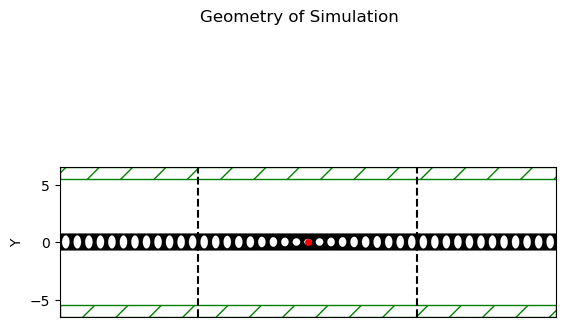

-----------
Initializing structure...
Halving computational cell along direction x
Halving computational cell along direction y
time for choose_chunkdivision = 0.00163388 s
Working in 2D dimensions.
Computational cell is 43 x 12.9688 x 0 with resolution 128
     block, center = (0,0,0)
          size (43,1.48368,0.652819)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     ellipsoid, center = (-9,0,0)
          size (0.646884,1.12166,0.652819)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     ellipsoid, center = (9,0,0)
          size (0.646884,1.12166,0.652819)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     ellipsoid, center = (-8,0,0)
          size (0.646884,1.10386,0.652819)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     ellipsoid, center = (8,0,0)
          size (0.

In [ ]:
taper = u.tapering(380, 180, 10)
res = [128, 256]
Qs = []
for i in res: 
    Qsi, freqs = u.defectandmirrors(500, length = 337, xlength= 218, ylengths = taper, mirrorlength=382, excitation = mp.Hz, nummirrors=12, findModes=True,
                                     modevisulization=False, resolution = i)
    Qs.append(Qsi)

In [5]:
print(max(Qs[0]), max(Qs[1]))

562978.3831430227 562978.3831430227


In [ ]:
Q_max = []
num_mirrors = range(1,15)
for i in num_mirrors: 
    Qsi, freqs = u.defectandmirrors(500, length = 337, xlength= 218, ylengths = taper, mirrorlength=382, excitation = mp.Hz, nummirrors=i, findModes=True, modevisulization=False)
    Q_max.append(max(Qsi))